# Analisi del dataset

Dataset KAt-DataCenter dell'Università di Paderborn (Lessmeier et al., 2016), lo stesso
usato da Toma, Piltan e Kim (2021).

La regola che seguiamo qui è una sola: non assumere niente dalla documentazione, misurare
tutto sui file. Frequenza di campionamento, durata, velocità e numero di coppie polari
li ricaviamo dai dati e poi li confrontiamo con quello che il banco prova dichiara.

Il notebook salva figure e tabelle in `risultati/01_analisi_dataset/`.
Le funzioni stanno in `funzioni.py`, le costanti e l'anagrafica dei cuscinetti in `config.py`.

## Setup

In [33]:
!apt-get -qq update && apt-get -qq install -y unrar
!pip -q install requests scipy pymupdf

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [34]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, hashlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = 'https://github.com/matpaol/MacchineEdAzionamentiExam'

# config.py e funzioni.py: prima li cerco accanto al notebook, poi su Drive.
# Se non ci sono clono il repo, cosi la cella funziona sia da Colab sia da VS Code
# collegato a un runtime Colab.
possibili = ['.',
             '/content/drive/MyDrive/MacchineEdAzionamentiExam',
             '/content/MacchineEdAzionamentiExam']

cartella_codice = None
for percorso in possibili:
    if os.path.exists(os.path.join(percorso, 'funzioni.py')):
        cartella_codice = percorso
        break

if cartella_codice is None:
    print('codice non trovato in locale, clono il repo')
    subprocess.run(['git', 'clone', '-q', REPO, '/content/MacchineEdAzionamentiExam'],
                   check=True)
    cartella_codice = '/content/MacchineEdAzionamentiExam'

cartella_codice = os.path.abspath(cartella_codice)
print('codice da', cartella_codice)

sys.path.insert(0, cartella_codice)
import config
import funzioni as fn

P = config.percorsi(sottocartella='01_analisi_dataset')
fn.stile_grafici()

for chiave, valore in P.items():
    print(chiave.ljust(12), valore)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
codice da /content/MacchineEdAzionamentiExam
radice       /content/drive/MyDrive/bearings_detection
raw          /content/drive/MyDrive/bearings_detection/raw
documenti    /content/drive/MyDrive/bearings_detection/documenti
estratti     /content/estratti
risultati    /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset
figure       /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure
tabelle      /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle


## Cosa offre il repository remoto?

Prima di scaricare qualunque cosa, guardiamo cosa c'è.

In [35]:
cuscinetti_remoti = fn.elenco_remoto()

tipi = {}
for nome in cuscinetti_remoti:
    prefisso = nome.rstrip('0123456789')
    tipi[prefisso] = tipi.get(prefisso, 0) + 1

print(len(cuscinetti_remoti), 'cuscinetti')
print(tipi)
print()
print('K sani, KA guasto pista esterna, KI guasto pista interna, KB danno combinato')

32 cuscinetti
{'K': 6, 'KA': 12, 'KB': 3, 'KI': 11}

K sani, KA guasto pista esterna, KI guasto pista interna, KB danno combinato


In [36]:
import requests
print(requests.get(config.URL_REPOSITORY + 'readme_versions.txt').text)

2016-07-13:  update of profile of bearing damage KI03 (correction of mistakes in description of damage geometry)


In [37]:
# Scarica solo quelli che mancano: al secondo avvio questa cella non fa nulla.
archivi, dimensione = fn.scarica_archivi(cuscinetti_remoti, P['raw'])
print(len(archivi), 'archivi |', round(dimensione / 1e9, 2), 'GB')

32 archivi | 5.36 GB


## Le schede dei cuscinetti

Ogni archivio contiene due PDF: la scheda del danno e il measuring log. Li estraiamo
senza scompattare i .mat, perché è da lì che viene l'anagrafica che usiamo più avanti.

In [38]:
schede = fn.estrai_schede(cuscinetti_remoti, P['raw'], P['documenti'])
for nome in sorted(schede)[:3]:
    print(nome, '->', schede[nome])
print('...')
print(len(schede), 'cuscinetti con le schede estratte')

K001 -> ['K001.pdf', 'measuring_log_K001.pdf']
K002 -> ['K002.pdf', 'measuring_log_K002.pdf']
K003 -> ['K003.pdf', 'measuring_log_K003.pdf']
...
32 cuscinetti con le schede estratte


## Cosa c'è dentro un file di misura?

Ogni registrazione è un file MATLAB con quattro campi: Info, X, Y, Description.
In Y stanno i segnali, in X gli assi dei tempi. La cosa da tenere a mente è che i segnali
non hanno tutti la stessa frequenza di campionamento: ognuno dichiara a quale asse
fa riferimento. Se li leggi assumendo un'unica frequenza, sbagli la segmentazione.

In [39]:
# I 17 cuscinetti della Tabella 2 del paper. La prima volta ci mette qualche minuto.
fn.estrai_misure(config.CUSCINETTI_PAPER, P['raw'], P['estratti'])

esempio = fn.elenco_registrazioni(['K001'], P['estratti'], [config.REGIME_PRINCIPALE])[0]
struct = fn.apri(esempio)

print(os.path.basename(esempio))
print('campi   ', list(struct.keys()))
print('segnali ', [s['Name'] for s in struct['Y']])
print('assi    ', [x['Raster'] for x in struct['X']])

N15_M07_F10_K001_1.mat
campi    ['Info', 'X', 'Y', 'Description']
segnali  ['force', 'phase_current_1', 'phase_current_2', 'speed', 'temp_2_bearing_module', 'torque', 'vibration_1']
assi     ['Mech_4kHz', 'HostService', 'Temp_1Hz']


## Quanto vale davvero la frequenza di campionamento?

Gli assi dei tempi contengono istanti, quindi il passo lo misuriamo invece di assumerlo.
Lo ricaviamo dall'intervallo complessivo diviso il numero di passi: sul singolo passo pesa
l'arrotondamento con cui il dato è stato salvato, sull'intero intervallo no.

In [40]:
fn.assi_dei_tempi(esempio, struct)

,raster,campioni,intervallo_s,frequenza_Hz
0,Mech_4kHz,16001,4.000000,4000.000428
1,HostService,256001,3.999999,64000.020531
2,Temp_1Hz,5,4.000000,1.000000


In [41]:
campionamento = fn.misura_campionamento(esempio, config.CANALE_CORRENTE, struct)

print('canale     ', config.CANALE_CORRENTE)
print('raster     ', campionamento['raster'])
print('campioni   ', campionamento['campioni'])
print('frequenza  ', round(campionamento['frequenza_Hz'], 4), 'Hz  contro',
      config.FS_ATTESO, 'nominali')
print('durata     ', round(campionamento['durata_s'], 6), 's')
print('scarto     ', round(campionamento['scarto_pct'], 4), '%')

rpm = config.REGIMI[config.REGIME_PRINCIPALE]['rpm']
print()
print('un giro a', rpm, 'rpm dura',
      fn.lunghezza_frame(rpm, campionamento['frequenza_Hz']), 'campioni')

canale      phase_current_1
raster      HostService
campioni    256001
frequenza   64000.0205 Hz  contro 64000 nominali
durata      4.000014 s
scarto      0.0 %

un giro a 1500 rpm dura 2560 campioni


In [42]:
tabella_canali = fn.canali(esempio, struct)
fn.salva_tabella(tabella_canali, 'canali_disponibili', P['tabelle'])
tabella_canali

tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/canali_disponibili.csv


,segnale,raster,campioni,frequenza_Hz,durata_s
1,phase_current_1,HostService,256001,64000.020531,4.000014
2,phase_current_2,HostService,256001,64000.020531,4.000014
6,vibration_1,HostService,256001,64000.020531,4.000014
0,force,Mech_4kHz,16001,4000.000428,4.000250
3,speed,Mech_4kHz,16001,4000.000428,4.000250
5,torque,Mech_4kHz,16001,4000.000428,4.000250
4,temp_2_bearing_module,Temp_1Hz,5,1.000000,4.999999


## Che aspetto hanno i segnali?

Sano e le due rotture a confronto, stesso regime.

figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/forme_onda_per_classe.png


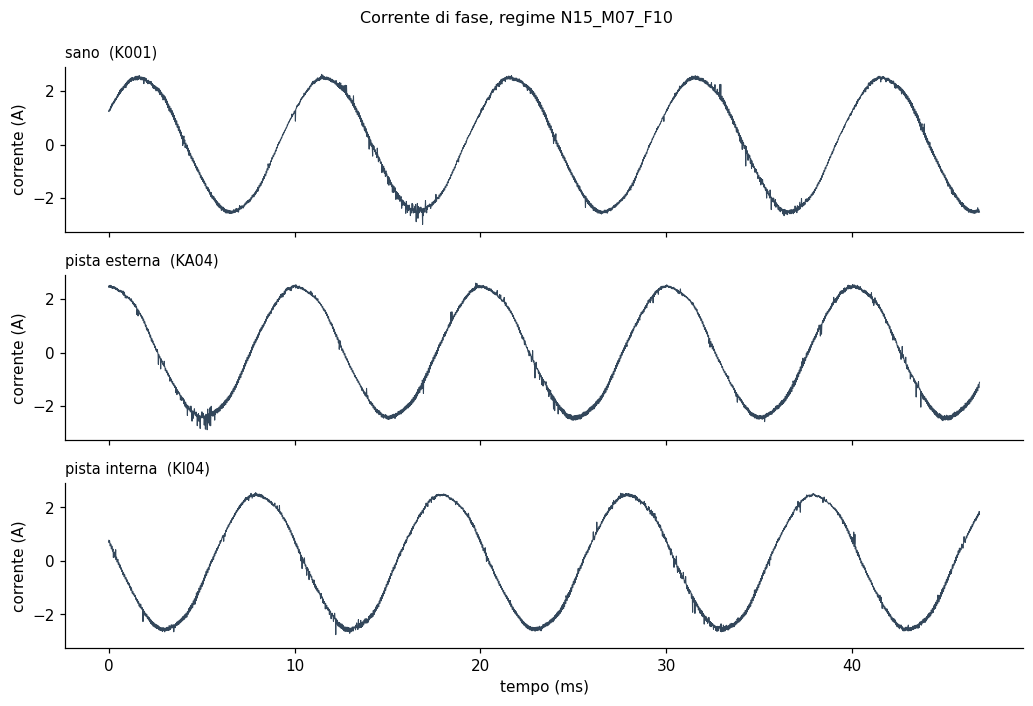

In [43]:
esempi = [('K001', 'sano'), ('KA04', 'pista esterna'), ('KI04', 'pista interna')]

fig, assi = plt.subplots(len(esempi), 1, figsize=(9.5, 6.5), sharex=True, sharey=True)
for ax, (cuscinetto, descrizione) in zip(assi, esempi):
    percorso = fn.elenco_registrazioni([cuscinetto], P['estratti'],
                                       [config.REGIME_PRINCIPALE])[0]
    x = fn.leggi(percorso, config.CANALE_CORRENTE)
    tempo = np.arange(3000) / config.FS_ATTESO * 1000
    ax.plot(tempo, x[:3000], linewidth=0.7, color=fn.COLORI['scuro'])
    ax.set_title(descrizione + '  (' + cuscinetto + ')', fontsize=9.5, loc='left')
    ax.set_ylabel('corrente (A)')
assi[-1].set_xlabel('tempo (ms)')
fig.suptitle('Corrente di fase, regime ' + config.REGIME_PRINCIPALE, fontsize=10.5)

fn.salva_figura(fig, 'forme_onda_per_classe', P['figure'])
plt.show()

## I dati sono puliti?

Una sola passata su tutte le registrazioni dei 17 cuscinetti, nei quattro regimi.
Per ogni file misuriamo frequenza e durata, calcoliamo le grandezze del corso
(Parte 20, Features Extraction) sulla corrente e sulla velocità, e salviamo un'impronta
del segnale che ci servirà per cercare eventuali duplicati. Tutto il resto del notebook
lavora su questa tabella.

In [44]:
percorsi_mat = fn.elenco_registrazioni(config.CUSCINETTI_PAPER, P['estratti'])
print(len(percorsi_mat), 'registrazioni da esaminare')

righe = []
partenza = time.time()

for k, percorso in enumerate(percorsi_mat, 1):
    riga = fn.metadati_nome(percorso)
    riga['classe'] = config.CLASSE_DI[riga['cuscinetto']]

    struct = fn.apri(percorso)
    corrente = fn.leggi(percorso, config.CANALE_CORRENTE, struct)
    velocita = fn.leggi(percorso, 'speed', struct)

    campionamento = fn.misura_campionamento(percorso, config.CANALE_CORRENTE, struct)
    riga['fs_Hz'] = campionamento['frequenza_Hz']
    riga['durata_s'] = campionamento['durata_s']
    riga['scarto_fs_pct'] = campionamento['scarto_pct']

    # Tutti i segnali si leggono a 64 kHz. Vedi la sezione sulle frequenze:
    # dove l'asse dei tempi dice altro, e l'asse a sbagliare.
    riga.update(fn.caratteristiche(corrente))

    giri = fn.stazionarieta(velocita)
    riga['rpm_medio'] = giri['media']
    riga['rpm_min'] = giri['minimo']
    riga['rpm_max'] = giri['massimo']
    riga['rpm_variazione_pct'] = giri['variazione_pct']
    riga['campioni_per_giro'] = fn.lunghezza_frame(giri['media'])

    riga['firma'] = hashlib.blake2b(np.ascontiguousarray(corrente).tobytes(),
                                    digest_size=8).hexdigest()
    righe.append(riga)

    if k % 200 == 0:
        print(' ', k, 'di', len(percorsi_mat), ' ', round(time.time() - partenza), 's')

scan = pd.DataFrame(righe)
print()
print('fatto in', round(time.time() - partenza), 's |', scan.shape)
fn.salva_tabella(scan.drop(columns=['file']), 'scansione_completa', P['tabelle'])

1360 registrazioni da esaminare
  200 di 1360   34 s
  400 di 1360   63 s
  600 di 1360   89 s
  800 di 1360   114 s
  1000 di 1360   149 s
  1200 di 1360   175 s

fatto in 193 s | (1360, 24)
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/scansione_completa.csv


'/content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/scansione_completa.csv'

In [45]:
# Se l'estrazione fosse incompleta non ce ne accorgeremmo dagli errori: semplicemente
# avremmo meno dati. Quindi contiamo.
riepilogo = (scan.groupby(['regime', 'classe'])
                 .agg(registrazioni=('registrazione', 'count'),
                      cuscinetti=('cuscinetto', 'nunique'))
                 .reset_index())
riepilogo['classe_nome'] = riepilogo['classe'].map(dict(enumerate(config.NOMI_CLASSI)))

atteso = len(config.CUSCINETTI_PAPER) * 20
print('attese', atteso, 'registrazioni per regime (17 cuscinetti per 20 ripetizioni)')
for regime, gruppo in scan.groupby('regime'):
    print(' ', regime, len(gruppo), 'ok' if len(gruppo) == atteso else 'INCOMPLETO')

fn.salva_tabella(riepilogo, 'inventario_per_regime_classe', P['tabelle'])
riepilogo

attese 340 registrazioni per regime (17 cuscinetti per 20 ripetizioni)
  N09_M07_F10 340 ok
  N15_M01_F10 340 ok
  N15_M07_F04 340 ok
  N15_M07_F10 340 ok
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/inventario_per_regime_classe.csv


,regime,classe,registrazioni,cuscinetti,classe_nome
0,N09_M07_F10,0,120,6,normale
1,N09_M07_F10,1,100,5,esterno
2,N09_M07_F10,2,120,6,interno
3,N15_M01_F10,0,120,6,normale
4,N15_M01_F10,1,100,5,esterno
5,N15_M01_F10,2,120,6,interno
6,N15_M07_F04,0,120,6,normale
7,N15_M07_F04,1,100,5,esterno
8,N15_M07_F04,2,120,6,interno
9,N15_M07_F10,0,120,6,normale


In [46]:
print('registrazioni      ', len(scan))
print('valori non finiti  ', int((scan['non_finiti'] > 0).sum()))
print('canali piatti      ', int((scan['std'] == 0).sum()))
print('durata: da', round(scan['durata_s'].min(), 4), 'a', round(scan['durata_s'].max(), 4), 's')
print('crest : da', round(scan['crest'].min(), 3), 'a', round(scan['crest'].max(), 3))
print()
print('le cinque registrazioni con il fattore di cresta piu alto:')
scan.nlargest(5, 'crest')[['registrazione', 'cuscinetto', 'regime', 'crest',
                           'rpm_variazione_pct']]

registrazioni       1360
valori non finiti   0
canali piatti       0
durata: da 4.0 a 4.6725 s
crest : da 1.646 a 2.449

le cinque registrazioni con il fattore di cresta piu alto:


,registrazione,cuscinetto,regime,crest,rpm_variazione_pct
484,N09_M07_F10_KA04_13.mat,KA04,N09_M07_F10,2.448810,16.580302
502,N15_M01_F10_KA04_11.mat,KA04,N15_M01_F10,2.305820,0.044717
500,N15_M01_F10_KA04_1.mat,KA04,N15_M01_F10,2.288450,0.062566
516,N15_M01_F10_KA04_6.mat,KA04,N15_M01_F10,2.253757,0.036455
510,N15_M01_F10_KA04_19.mat,KA04,N15_M01_F10,2.245016,0.036173


## Con che frequenze stiamo lavorando davvero?

Il banco dichiara 64 kHz per la corrente. Misurando la frequenza dall'asse dei tempi di
ogni file, pero, una parte delle registrazioni sembra campionata molto piu in fretta,
fino a 73 kHz. Prima di crederci conviene controllare, perche da questo numero dipende
la lunghezza del frame corrispondente a un giro meccanico.

Il controllo ce lo da la fisica. Il motore ha quattro coppie polari, la velocita la
misuriamo dal canale `speed` che sta su un altro raster, quindi la fondamentale della
corrente deve valere quattro volte la frequenza di rotazione: 100 Hz a 1500 rpm.
Interpretando tutti i segnali a 64 kHz quel conto torna, anche per le registrazioni
che l'asse dei tempi dichiara piu veloci.

Quindi il campionamento e uniforme a 64 kHz, e a non essere coerente e l'asse dei tempi
di quei file. Non si ricampiona niente: si legge tutto a 64 kHz e un giro a 1500 rpm
dura 2560 campioni, come prescrive il paper.

In [47]:
print(scan['fs_Hz'].describe().round(2).to_string())
print()

sospette = scan[scan['scarto_fs_pct'].abs() > 100 * config.TOLLERANZA]
print(len(sospette), 'registrazioni su', len(scan),
      'hanno un asse dei tempi incoerente col proprio numero di campioni')
print('scarto massimo apparente:', round(scan['scarto_fs_pct'].abs().max(), 2), '%')
print()
print(sospette['cuscinetto'].value_counts().to_string())

count     1360.00
mean     64153.79
std        724.11
min      63998.93
25%      64000.01
50%      64000.09
75%      64020.44
max      72961.55

181 registrazioni su 1360 hanno un asse dei tempi incoerente col proprio numero di campioni
scarto massimo apparente: 14.0 %

cuscinetto
K006    25
K001    22
K003    19
K005    19
KI04    13
K004    12
KI16    10
KI14     9
KI17     9
KA04     8
KI21     7
KA16     7
KA22     6
K002     5
KA30     4
KA15     3
KI18     3


In [48]:
# La verifica: se quei file fossero davvero campionati piu in fretta, letti a 64 kHz
# mostrerebbero una fondamentale piu bassa in proporzione. Invece mostrano 100 Hz
# come tutti gli altri, quindi a 64 kHz ci sono davvero.
confronto = pd.DataFrame({
    'coerenti': scan.loc[scan['scarto_fs_pct'].abs() <= 100 * config.TOLLERANZA,
                         'f_dominante'].describe(),
    'sospette': sospette['f_dominante'].describe(),
}).round(4)
print(confronto.to_string())
print()
print('a 1500 rpm un giro dura', fn.lunghezza_frame(1500), 'campioni per tutte')

        coerenti  sospette
count  1179.0000  181.0000
mean     89.8841   90.6792
std      17.3903   16.9266
min      59.9670   59.8615
25%      60.0002   99.8506
50%      99.9992   99.9181
75%      99.9996   99.9871
max     100.0016  100.0945

a 1500 rpm un giro dura 2560 campioni per tutte


figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/frequenze_di_campionamento.png
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/frequenze_per_cuscinetto.csv


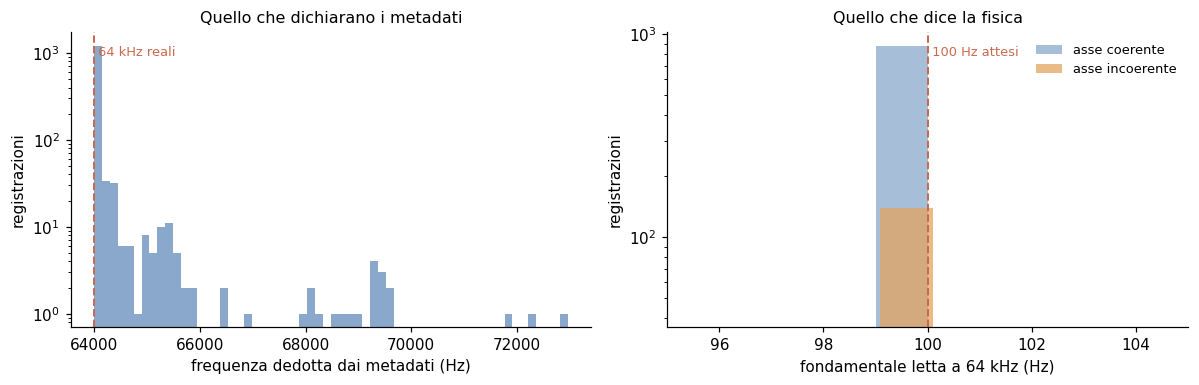

In [49]:
fig, (sinistra, destra) = plt.subplots(1, 2, figsize=(11, 3.6))

sinistra.hist(scan['fs_Hz'], bins=60, color=fn.COLORI['normale'])
sinistra.axvline(config.FS_ATTESO, color=fn.COLORI['accento'], linestyle='--', linewidth=1.3)
sinistra.text(config.FS_ATTESO, sinistra.get_ylim()[1] * 0.95, ' 64 kHz reali',
              color=fn.COLORI['accento'], fontsize=8.5, va='top')
sinistra.set_xlabel('frequenza dedotta dai metadati (Hz)')
sinistra.set_ylabel('registrazioni')
sinistra.set_yscale('log')
sinistra.set_title('Quello che dichiarano i metadati')

for etichetta, parte, colore in [
        ('asse coerente', scan[scan['scarto_fs_pct'].abs() <= 100 * config.TOLLERANZA],
         fn.COLORI['normale']),
        ('asse incoerente', sospette, fn.COLORI['esterno'])]:
    destra.hist(parte['f_dominante'], bins=40, alpha=0.75, label=etichetta, color=colore)
destra.axvline(100, color=fn.COLORI['accento'], linestyle='--', linewidth=1.3)
destra.text(100, destra.get_ylim()[1] * 0.95, ' 100 Hz attesi',
            color=fn.COLORI['accento'], fontsize=8.5, va='top')
destra.set_xlabel('fondamentale letta a 64 kHz (Hz)')
destra.set_ylabel('registrazioni')
destra.set_yscale('log')
destra.set_xlim(95, 105)
destra.legend(fontsize=8.5)
destra.set_title('Quello che dice la fisica')

fn.salva_figura(fig, 'frequenze_di_campionamento', P['figure'])
fn.salva_tabella(scan.groupby('cuscinetto')[['fs_Hz', 'scarto_fs_pct', 'f_dominante']]
                     .agg(['mean', 'min', 'max']).round(3).reset_index(),
                 'frequenze_per_cuscinetto', P['tabelle'])
plt.show()

## Le grandezze cambiano tra sano e guasto?

Se bastassero le statistiche nel dominio del tempo non servirebbe nessun autoencoder.

              std     picco       rms     crest         zcr  f_dominante
normale  1.720903  2.957629  1.720909  1.736581  652.020571    99.999414
esterno  1.704992  2.953840  1.705351  1.741730  636.515596    99.999219
interno  1.721528  2.952463  1.721848  1.732732  624.910370    99.999219
figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/statistiche_per_classe.png
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/statistiche_mediane_per_classe.csv


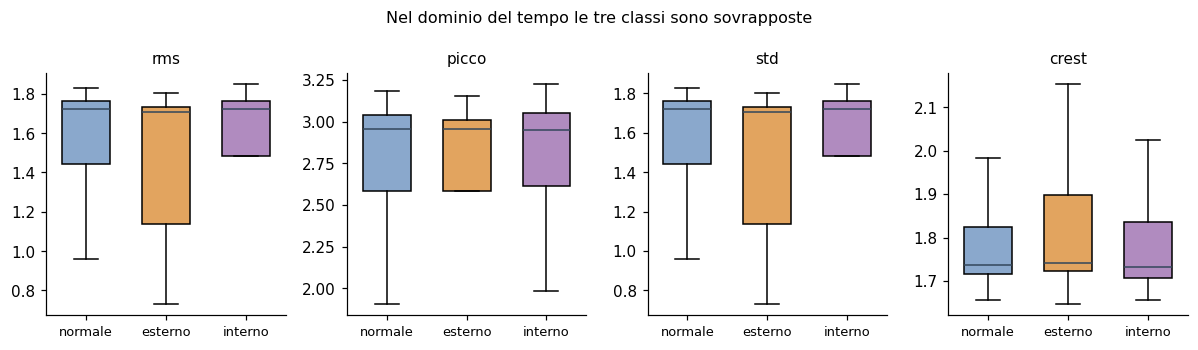

In [50]:
per_classe = scan.groupby('classe')[['std', 'picco', 'rms', 'crest', 'zcr', 'f_dominante']].median()
per_classe.index = [config.NOMI_CLASSI[i] for i in per_classe.index]
print(per_classe.to_string())

grandezze = ['rms', 'picco', 'std', 'crest']
colori = [fn.COLORI['normale'], fn.COLORI['esterno'], fn.COLORI['interno']]

fig, assi = plt.subplots(1, len(grandezze), figsize=(11, 3.2))
for ax, grandezza in zip(assi, grandezze):
    valori = [scan.loc[scan['classe'] == c, grandezza] for c in range(3)]
    scatole = ax.boxplot(valori, patch_artist=True, widths=0.6, showfliers=False,
                         medianprops=dict(color=fn.COLORI['scuro']))
    for corpo, colore in zip(scatole['boxes'], colori):
        corpo.set_facecolor(colore)
    ax.set_xticks(range(1, 4))
    ax.set_xticklabels(config.NOMI_CLASSI, fontsize=8.5)
    ax.set_title(grandezza, fontsize=10)
fig.suptitle('Nel dominio del tempo le tre classi sono sovrapposte', fontsize=10.5)

fn.salva_figura(fig, 'statistiche_per_classe', P['figure'])
fn.salva_tabella(per_classe.reset_index().rename(columns={'index': 'classe'}),
                 'statistiche_mediane_per_classe', P['tabelle'])
plt.show()

## Guardiamo il caso piu estremo

N09_M07_F10_KA04_13.mat | crest 2.45 | velocita variabile del 16.58 %
figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/registrazione_anomala.png


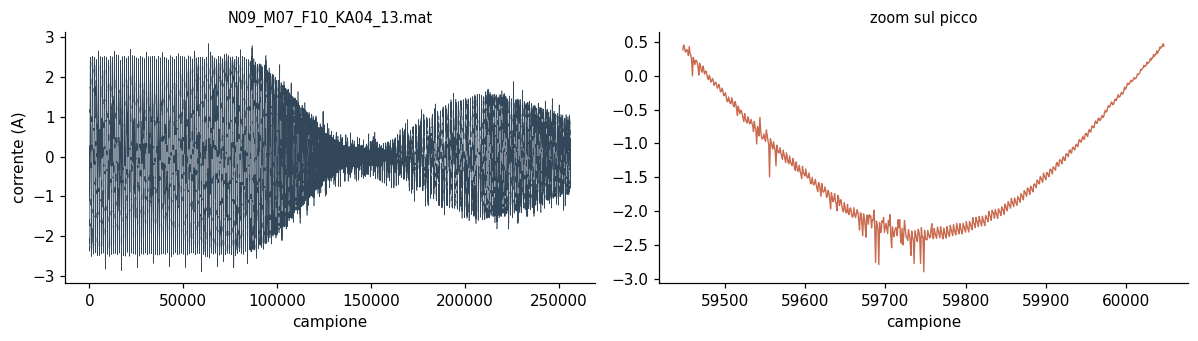

In [51]:
peggiore = scan.nlargest(1, 'crest').iloc[0]
print(peggiore['registrazione'],
      '| crest', round(peggiore['crest'], 2),
      '| velocita variabile del', round(peggiore['rpm_variazione_pct'], 2), '%')

x = fn.leggi(peggiore['file'], config.CANALE_CORRENTE)
indice = int(np.argmax(np.abs(x)))
da = max(0, indice - 300)

fig, (sinistra, destra) = plt.subplots(1, 2, figsize=(11, 3.2))
sinistra.plot(x, linewidth=0.4, color=fn.COLORI['scuro'])
sinistra.set_title(peggiore['registrazione'], fontsize=9.5)
sinistra.set_xlabel('campione')
sinistra.set_ylabel('corrente (A)')
destra.plot(range(da, indice + 300), x[da:indice + 300],
            linewidth=0.9, color=fn.COLORI['accento'])
destra.set_title('zoom sul picco', fontsize=9.5)
destra.set_xlabel('campione')

fn.salva_figura(fig, 'registrazione_anomala', P['figure'])
plt.show()

## La velocita e costante dentro una registrazione?

In [52]:
print(scan.groupby('regime')[['rpm_medio', 'rpm_variazione_pct']].mean().to_string())
print()

scan['rpm_nominale'] = scan['regime'].map(lambda r: config.REGIMI[r]['rpm'])
scan['scarto_pct'] = 100 * (scan['rpm_medio'] - scan['rpm_nominale']) / scan['rpm_nominale']
print(scan.groupby('regime')[['rpm_nominale', 'rpm_medio', 'scarto_pct']].mean().to_string())

               rpm_medio  rpm_variazione_pct
regime                                      
N09_M07_F10   899.821407            0.115248
N15_M01_F10  1499.619925            0.035946
N15_M07_F04  1499.590132            0.044083
N15_M07_F10  1499.601332            0.037129

             rpm_nominale    rpm_medio  scarto_pct
regime                                            
N09_M07_F10         900.0   899.821407   -0.019844
N15_M01_F10        1500.0  1499.619925   -0.025338
N15_M07_F04        1500.0  1499.590132   -0.027325
N15_M07_F10        1500.0  1499.601332   -0.026578


## Quante coppie polari ha il motore?

Questa verifica risponde a una domanda piu grossa: il motore del banco e sincrono o asincrono?
Il paper presenta il lavoro come diagnosi su motori a induzione, ma nella descrizione del banco
riporta un motore sincrono a magneti permanenti.

Sui dati si distingue facilmente. Per una macchina sincrona il rapporto fra frequenza elettrica
e frequenza di rotazione vale esattamente il numero di coppie polari, e non dipende dal carico.
Per una macchina asincrona lo stesso rapporto vale p / (1 - s), e siccome lo scorrimento cresce
con la coppia resistente, cambia col carico. Quindi basta calcolarlo nei quattro regimi.

             giri_al_secondo  f_dominante  rapporto  coppia_Nm  forza_N
regime                                                                 
N09_M07_F10        14.995756    59.999766  4.000985        0.7     1000
N15_M01_F10        24.993433    99.999609  4.000954        0.1     1000
N15_M07_F04        24.993333    99.999609  4.000997        0.7      400
N15_M07_F10        24.993146    99.999609  4.000987        0.7     1000

scarto massimo da 4 : 0.000997
figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/coppie_polari.png
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/rapporto_coppie_polari.csv


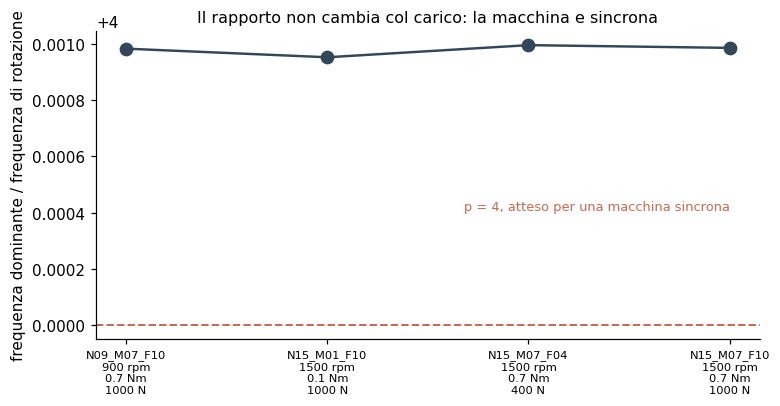

In [53]:
scan['giri_al_secondo'] = scan['rpm_medio'] / 60.0
scan['rapporto'] = scan['f_dominante'] / scan['giri_al_secondo']

coppie = scan.groupby('regime')[['giri_al_secondo', 'f_dominante', 'rapporto']].median()
coppie['coppia_Nm'] = [config.REGIMI[r]['coppia_Nm'] for r in coppie.index]
coppie['forza_N'] = [config.REGIMI[r]['forza_N'] for r in coppie.index]
print(coppie.to_string())

p = round(coppie['rapporto'].mean())
print()
print('scarto massimo da', p, ':', round((coppie['rapporto'] - p).abs().max(), 6))

ordine = ['N09_M07_F10', 'N15_M01_F10', 'N15_M07_F04', 'N15_M07_F10']
etichette = [r + '\n' + str(config.REGIMI[r]['rpm']) + ' rpm\n'
             + str(config.REGIMI[r]['coppia_Nm']) + ' Nm\n'
             + str(config.REGIMI[r]['forza_N']) + ' N' for r in ordine]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(range(len(ordine)), coppie.loc[ordine, 'rapporto'], 'o-',
        color=fn.COLORI['scuro'], markersize=8, linewidth=1.6, zorder=3)
ax.axhline(p, color=fn.COLORI['accento'], linestyle='--', linewidth=1.3, zorder=2)
ax.text(len(ordine) - 1, p + 0.0004, 'p = ' + str(p) + ', atteso per una macchina sincrona',
        color=fn.COLORI['accento'], ha='right', va='bottom', fontsize=8.5)
ax.set_xticks(range(len(ordine)))
ax.set_xticklabels(etichette, fontsize=7.5)
ax.set_ylabel('frequenza dominante / frequenza di rotazione')
ax.set_title('Il rapporto non cambia col carico: la macchina e sincrona')

fn.salva_figura(fig, 'coppie_polari', P['figure'])
fn.salva_tabella(coppie.reset_index(), 'rapporto_coppie_polari', P['tabelle'])
plt.show()

## Ci sono registrazioni duplicate?

Il measuring log di KA04 dice che un file conteneva dati errati e fu sostituito con la copia
di un altro. Verifichiamo per conto nostro, confrontando le impronte dei segnali, se ci siano
registrazioni identiche, documentate o meno.

Non e un dettaglio: con una suddivisione casuale dei segmenti, due registrazioni identiche
finiscono di sicuro una in addestramento e una in verifica.

In [54]:
doppie = scan[scan.duplicated('firma', keep=False)]
print(len(doppie), 'registrazioni hanno un contenuto identico a un altra')

if len(doppie):
    print('cuscinetti coinvolti:', sorted(doppie['cuscinetto'].unique()))
    print()
    print(doppie.sort_values(['cuscinetto', 'regime', 'firma'])
               [['cuscinetto', 'regime', 'registrazione', 'firma']].to_string(index=False))
    fn.salva_tabella(doppie[['cuscinetto', 'regime', 'registrazione', 'firma']],
                     'registrazioni_duplicate', P['tabelle'])

7 registrazioni hanno un contenuto identico a un altra
cuscinetti coinvolti: ['KA04']

cuscinetto      regime           registrazione            firma
      KA04 N09_M07_F10 N09_M07_F10_KA04_17.mat e1153ee0372612e0
      KA04 N09_M07_F10 N09_M07_F10_KA04_18.mat e1153ee0372612e0
      KA04 N15_M07_F04 N15_M07_F04_KA04_15.mat 690a2d62cec526fb
      KA04 N15_M07_F04 N15_M07_F04_KA04_20.mat 690a2d62cec526fb
      KA04 N15_M07_F04  N15_M07_F04_KA04_6.mat 690a2d62cec526fb
      KA04 N15_M07_F04 N15_M07_F04_KA04_19.mat ed5a8b3b2bc11acf
      KA04 N15_M07_F04  N15_M07_F04_KA04_5.mat ed5a8b3b2bc11acf
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/registrazioni_duplicate.csv


## Cosa dicono le schede dei cuscinetti?

Le schede descrivono ogni esemplare: quanto ha girato prima delle misure, con che meccanismo
si e danneggiato, su quale anello, quanto e esteso il danno e chi lo ha costruito. Sono cose
che dai segnali non si ricavano, e mostrano che le tre classi non sono affatto omogenee.

In [55]:
anagrafica = fn.anagrafica_cuscinetti()
fn.salva_tabella(anagrafica, 'anagrafica_cuscinetti', P['tabelle'])

sani = anagrafica[anagrafica['classe'] == 0].sort_values('ore')
print('ore di funzionamento dei cuscinetti sani prima delle misure')
print(sani[['cuscinetto', 'ore', 'produttore']].to_string(index=False))
print()
print('fra il piu usato e il meno usato ci sono', round(sani['ore'].max() / sani['ore'].min()), 'volte')

tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/anagrafica_cuscinetti.csv
ore di funzionamento dei cuscinetti sani prima delle misure
cuscinetto  ore produttore
      K003  1.0        IBU
      K004  5.0        IBU
      K005 10.0        IBU
      K006 16.0        IBU
      K002 19.0        IBU
      K001 50.0        IBU

fra il piu usato e il meno usato ci sono 50 volte


In [56]:
guasti = anagrafica[anagrafica['classe'] > 0]
print(guasti[['cuscinetto', 'classe_nome', 'modo', 'caratteristica',
              'estensione', 'secondario']].to_string(index=False))

cuscinetto classe_nome                  modo caratteristica  estensione                  secondario
      KA04     esterno                fatica       puntuale           1                        None
      KA15     esterno deformazione plastica       puntuale           1                        None
      KA16     esterno                fatica       puntuale           2                        None
      KA22     esterno                fatica       puntuale           1                        None
      KA30     esterno deformazione plastica    distribuito           1                        None
      KI04     interno                fatica       puntuale           1 deformazione plastica su OR
      KI14     interno                fatica       puntuale           1 deformazione plastica su OR
      KI16     interno                fatica       puntuale           3                        None
      KI17     interno                fatica       puntuale           1                        None


In [57]:
print(pd.crosstab(anagrafica['classe_nome'], anagrafica['produttore']).to_string())

e_ibu = anagrafica['produttore'].str.startswith('IBU')
azzeccati = int(((anagrafica['classe'] == 0) == e_ibu).sum())
print()
print('la regola "se e IBU allora e sano" ne indovina', azzeccati, 'su', len(anagrafica))
print('classe e produttore sono quasi la stessa cosa')

produttore   FAG  IBU  IBU/IBB  MTK
classe_nome                        
esterno        2    0        1    2
interno        2    0        0    4
normale        0    6        0    0

la regola "se e IBU allora e sano" ne indovina 16 su 17
classe e produttore sono quasi la stessa cosa


figura salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/figure/natura_cuscinetti.png


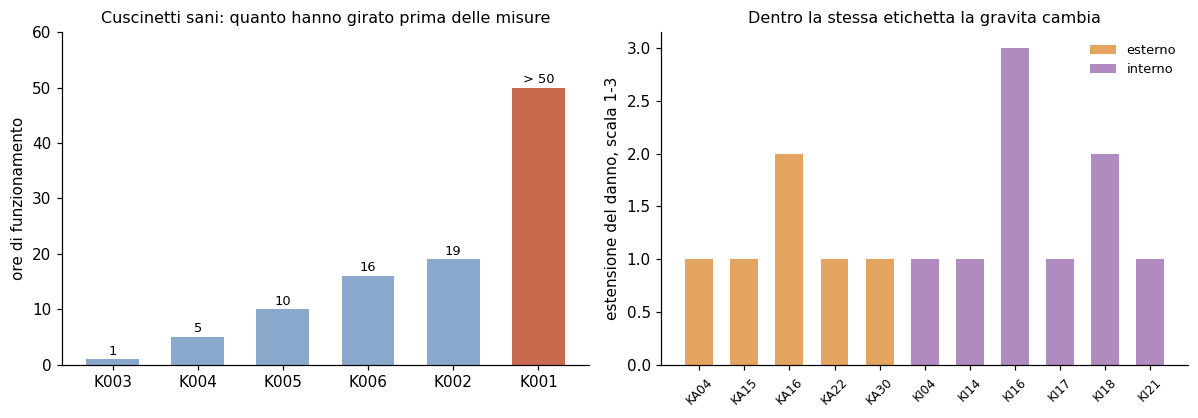

In [58]:
fig, (sinistra, destra) = plt.subplots(1, 2, figsize=(11, 3.9))

barre = sinistra.bar(sani['cuscinetto'], sani['ore'], width=0.62,
                     color=[fn.COLORI['normale']] * (len(sani) - 1) + [fn.COLORI['accento']])
for barra, ore in zip(barre, sani['ore']):
    testo = '> 50' if ore >= 50 else str(int(ore))
    sinistra.annotate(testo, (barra.get_x() + barra.get_width() / 2, ore),
                      textcoords='offset points', xytext=(0, 3), ha='center', fontsize=8.5)
sinistra.set_ylabel('ore di funzionamento')
sinistra.set_title('Cuscinetti sani: quanto hanno girato prima delle misure')
sinistra.set_ylim(0, sani['ore'].max() * 1.2)

for classe, colore in [(1, fn.COLORI['esterno']), (2, fn.COLORI['interno'])]:
    parte = anagrafica[anagrafica['classe'] == classe].sort_values('cuscinetto')
    destra.bar(parte['cuscinetto'], parte['estensione'], width=0.62, color=colore,
               label=config.NOMI_CLASSI[classe])
destra.set_ylabel('estensione del danno, scala 1-3')
destra.set_title('Dentro la stessa etichetta la gravita cambia')
destra.tick_params(axis='x', labelsize=8, rotation=45)
destra.legend(fontsize=8.5)

fn.salva_figura(fig, 'natura_cuscinetti', P['figure'])
plt.show()

## Le frequenze di guasto sono uguali per tutti?

No, perche il diametro primitivo dipende dal costruttore.

In [59]:
rpm = config.REGIMI[config.REGIME_PRINCIPALE]['rpm']
righe = []
for diametro in sorted(set(config.DIAMETRO_PRIMITIVO_MM.values())):
    f = fn.frequenze_guasto(rpm / 60.0, D=diametro)
    quali = sorted(nome for nome, d in config.DIAMETRO_PRIMITIVO_MM.items() if d == diametro)
    righe.append({'diametro_primitivo_mm': diametro, 'costruttori': ', '.join(quali),
                  'BPFO_Hz': f['BPFO'], 'BPFI_Hz': f['BPFI'],
                  'BSF_Hz': f['BSF'], 'FTF_Hz': f['FTF']})

frequenze = pd.DataFrame(righe)
print('a', rpm, 'rpm')
print(frequenze.round(2).to_string(index=False))
print()
print('su BPFO ballano', round(abs(frequenze['BPFO_Hz'].diff().iloc[-1]), 2), 'Hz')

fn.salva_tabella(frequenze, 'frequenze_caratteristiche', P['tabelle'])

a 1500 rpm
 diametro_primitivo_mm       costruttori  BPFO_Hz  BPFI_Hz  BSF_Hz  FTF_Hz
                 28.55               FAG    76.36   123.64   49.92    9.54
                 29.05 IBU, IBU/IBB, MTK    76.76   123.24   50.89    9.60

su BPFO ballano 0.41 Hz
tabella salvata: /content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/frequenze_caratteristiche.csv


'/content/drive/MyDrive/bearings_detection/risultati/01_analisi_dataset/tabelle/frequenze_caratteristiche.csv'

## Cosa abbiamo prodotto

In [60]:
print('figure')
for nome in sorted(os.listdir(P['figure'])):
    print('  ', nome)

print()
print('tabelle')
for nome in sorted(os.listdir(P['tabelle'])):
    print('  ', nome)

print()
print('registrazioni esaminate ', len(scan))
print('cuscinetti              ', scan['cuscinetto'].nunique())
print('regimi                  ', scan['regime'].nunique())
print('frequenza misurata      ', round(scan['fs_Hz'].mean(), 4), 'Hz')
print('assi dei tempi incoerenti', int((scan['scarto_fs_pct'].abs() > 0.1).sum()))
print('scarto massimo su fs    ', round(scan['scarto_fs_pct'].abs().max(), 2), '%')
print('registrazioni duplicate ', len(doppie))
print('coppie polari           ', round(scan['rapporto'].median(), 4))

figure
   coppie_polari.png
   forme_onda_per_classe.png
   frequenze_di_campionamento.png
   natura_cuscinetti.png
   registrazione_anomala.png
   statistiche_per_classe.png

tabelle
   anagrafica_cuscinetti.csv
   canali_disponibili.csv
   frequenze_caratteristiche.csv
   frequenze_per_cuscinetto.csv
   inventario_per_regime_classe.csv
   rapporto_coppie_polari.csv
   registrazioni_duplicate.csv
   scansione_completa.csv
   statistiche_mediane_per_classe.csv

registrazioni esaminate  1360
cuscinetti               17
regimi                   4
frequenza misurata       64153.7916 Hz
assi dei tempi incoerenti 181
scarto massimo su fs     14.0 %
registrazioni duplicate  7
coppie polari            4.001
